Figure1: 

climatology of blocks and tracks as upper panel. Blocking frequecny (%): contours; track points: plot the genenis points and the first interacting points (color represent the entry time percentage)

and timing as histogram as the inner panel. Only focus on anticylones and Ridge blocks. 


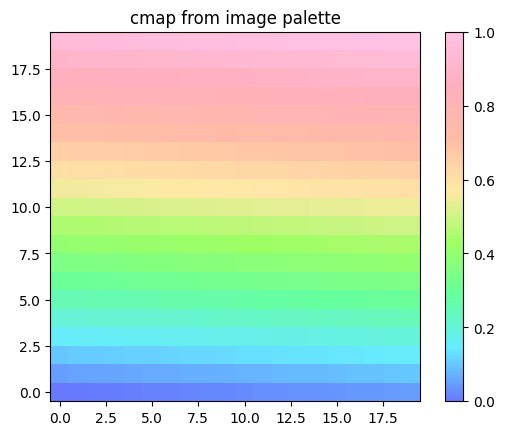

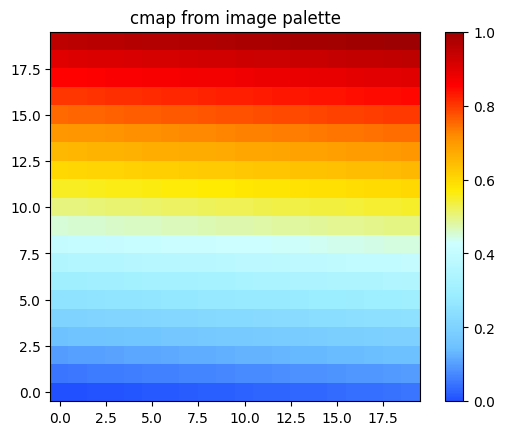

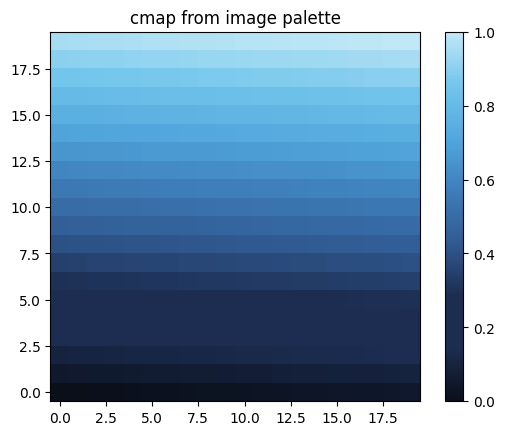

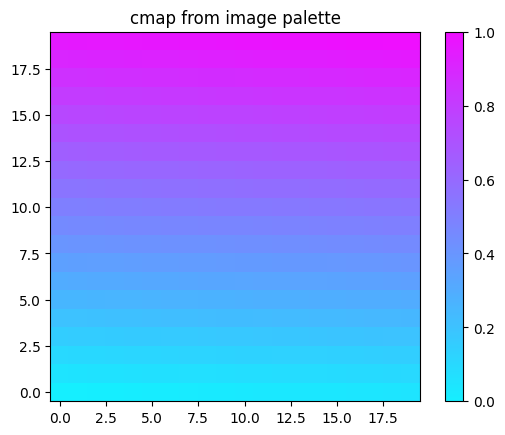

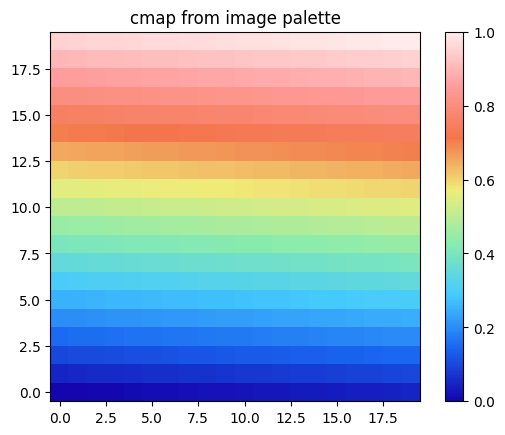

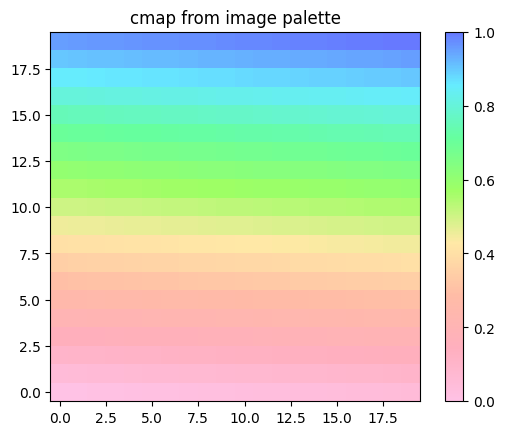

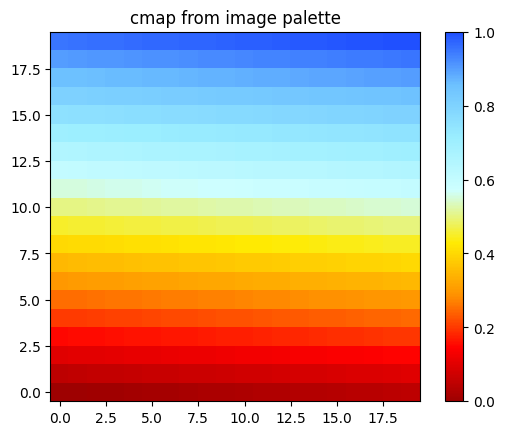

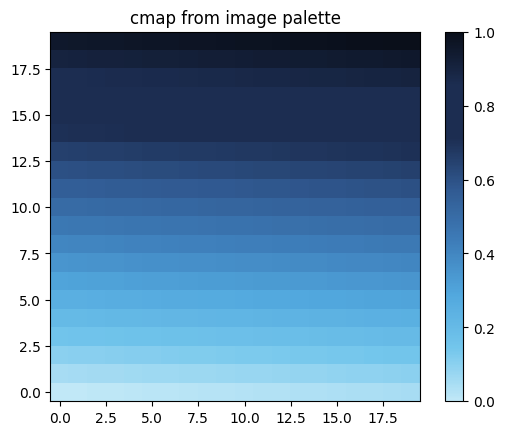

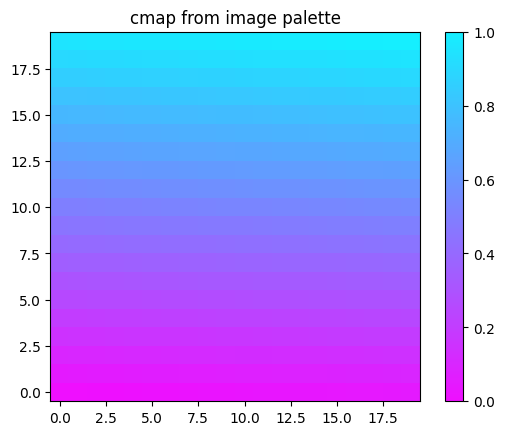

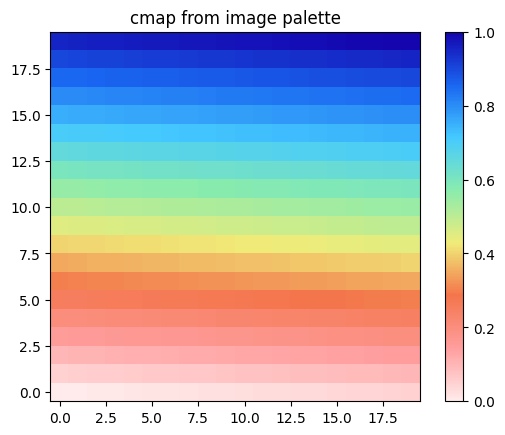

In [1]:
import numpy as np
import datetime as dt
from datetime import date
from datetime import datetime
from matplotlib import pyplot as plt
import cmocean
# from HYJfunction import *
import math
import time

from netCDF4 import Dataset
import pandas as pd
from dateutil.relativedelta import relativedelta
import matplotlib.colors
import os
import cartopy
from cartopy import crs as ccrs
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from scipy import ndimage
from multiprocessing import Pool, Manager
import cartopy.feature as cfeature
from scipy.ndimage import convolve
from scipy.signal import detrend
import pickle
import xarray as xr
import regionmask
from matplotlib.patches import Polygon
import matplotlib.path as mpath
from matplotlib.lines import Line2D
from multiprocessing import Pool, Manager
from matplotlib.colors import BoundaryNorm, ListedColormap
import seaborn as sns
import imageio
from scipy import stats
from collections import defaultdict
from scipy.ndimage import label
from scipy.interpolate import interp2d
import sys
import os
from cartopy.util import add_cyclic_point
import gmtColors

# %% function --------------------------------
regions = ["ATL", "NP", "SP"]
seasons = ["DJF", "JJA", "ALL"]
seasonsmonths = [[12, 1, 2], [6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["CC", "AC"]
eventType = ["Blocking", "Seeding"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def findClosest(lati, latids):

    if isinstance(lati, (np.ndarray, list)):  # if lat is an array or list
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 

def getSectorValues(data, lat_min, lat_max, lon_min, lon_max, lat, lon):
    lat_indices = (lat >= lat_min) & (lat <= lat_max)
    lon_indices = (lon >= lon_min) & (lon <= lon_max)
    if lon_min > lon_max:
        lon_indices = (lon >= lon_min) | (lon <= lon_max)
    lat_indices = np.where(lat_indices)[0]
    lon_indices = np.where(lon_indices)[0]

    lat_indices, lon_indices = np.ix_(lat_indices, lon_indices)

    region_mask = np.zeros_like(data, dtype=bool)
    region_mask[:, lat_indices, lon_indices] = True

    data_filtered = np.where(region_mask, data, 0)

    return region_mask[0,:,:], data_filtered


In [2]:

def create_Map(lon, lat, M, minv, maxv, interv=7, continterv = None, fill=True, ax=None, 
               leftlon=-180, rightlon=180, lowerlat=20, upperlat=90, centralLon=0, extend='both', alpha=1,
               fig=None, nrows=1, ncols=1, index=1, figsize=(15, 18),
               colr='coolwarm',contourcolr='gray', title=None, axisfontsize=12):

    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import xarray as xr
    import numpy as np
    from matplotlib.patches import Polygon
    import matplotlib.path as mpath
    from matplotlib.lines import Line2D

    # lon = ((lon + 180) % 360) - 180
    # lon = lon-180
    proj = ccrs.PlateCarree(central_longitude=centralLon)
    img_extent = [leftlon, rightlon, lowerlat, upperlat]
    # If not provided, create a new figure
    if fig is None:
        fig = plt.figure(figsize=figsize)   
    if ax == None:
        ax = fig.add_subplot(nrows, ncols, index, projection = proj)
        ax.set_extent(img_extent, ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('110m'))
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                          color='gray', linestyle='--', alpha=0.5)
        gl.xlabel_style = {'size': axisfontsize}
        gl.ylabel_style = {'size': axisfontsize}

    if fill==True:
        cf = ax.contourf(lon,lat,M,transform=ccrs.PlateCarree(),cmap=colr,levels=np.linspace(minv, maxv, interv), extend=extend, alpha=alpha)
    else:
        cf = ax.contour(lon,lat,M,transform=ccrs.PlateCarree(),colors=contourcolr,levels=np.arange(minv, maxv+continterv, continterv), negative_linestyles = 'dashed')
        ax.clabel(cf, inline=True, fontsize=8, fmt='%1.1f', colors=contourcolr, use_clabeltext=True)

    if title:
        ax.set_title(title)
    
    plt.tight_layout()
    
    return fig, ax, cf


def addSegments(ax,points,colr='black',linewidth=2,labels=None,alpha=1,linestyle='solid', zorder=4):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import xarray as xr
    import numpy as np
    from matplotlib.patches import Polygon
    import matplotlib.path as mpath
    from matplotlib.lines import Line2D
    
    # segments = []
    # for i in range(len(points) - 1):
    #     segment = [points[i], points[i + 1]]
    #     segments.append(segment)

    segments = []
    for i in range(len(points) - 1):
        lon1, lat1 = points[i]
        lon2, lat2 = points[i + 1]
        if lon1<0 or lon2<0:
            print('Longitude should be within 0-360 degrees')
        # if the longitude crosses 0 degrees, we need to split the line into two segments
        if abs(lon1 - lon2) > 180:
            
            lonm1 = 0 if lon1 < abs(360 - lon1) else 360
            lonm2 = 0 if lon2 < abs(360 - lon2) else 360
            segments.append([(lon1, lat1), (lonm1, (lat1+lat2)/2)])
            segments.append([(lonm2, (lat1+lat2)/2), (lon2, lat2)])
        else:
            segments.append([(lon1, lat1), (lon2, lat2)])

    colr = [colr] * len(segments)
    
    for i, line_segment in enumerate(segments):
        
        lons = [p[0] for p in line_segment]
        lats = [p[1] for p in line_segment]        
        color = colr[i]  # get the color      
        line = Line2D(
            lons, lats, 
            color=color,  # set color
            linewidth=linewidth, 
            transform=ccrs.PlateCarree(),
            alpha=alpha,
            linestyle=linestyle,
            zorder=zorder
        )        
        ax.add_line(line)
        # if labels are provided, add them
        if labels is not None:
            # calculate the mid point of each segment
            mid_lon = (lons[0] + lons[1]) / 2
            mid_lat = (lats[0] + lats[1]) / 2
            # add the label
            ax.text(mid_lon, mid_lat, labels[i], fontsize=5, 
                ha='center', transform=ccrs.PlateCarree())


In [3]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

1 AC ERA5 1009 308 856
1 AC MERRA2 981 328 861
1 AC JRA3Q 1004 347 865
1 CC ERA5 586 188 380
1 CC MERRA2 589 182 384
1 CC JRA3Q 583 175 367
2 AC ERA5 84 477 49
2 AC MERRA2 80 432 53
2 AC JRA3Q 84 454 46
2 CC ERA5 372 1383 316
2 CC MERRA2 412 1356 314
2 CC JRA3Q 397 1344 306
3 AC ERA5 119 127 83
3 AC MERRA2 123 125 96
3 AC JRA3Q 124 141 107
3 CC ERA5 185 197 69
3 CC MERRA2 182 203 80
3 CC JRA3Q 187 184 83


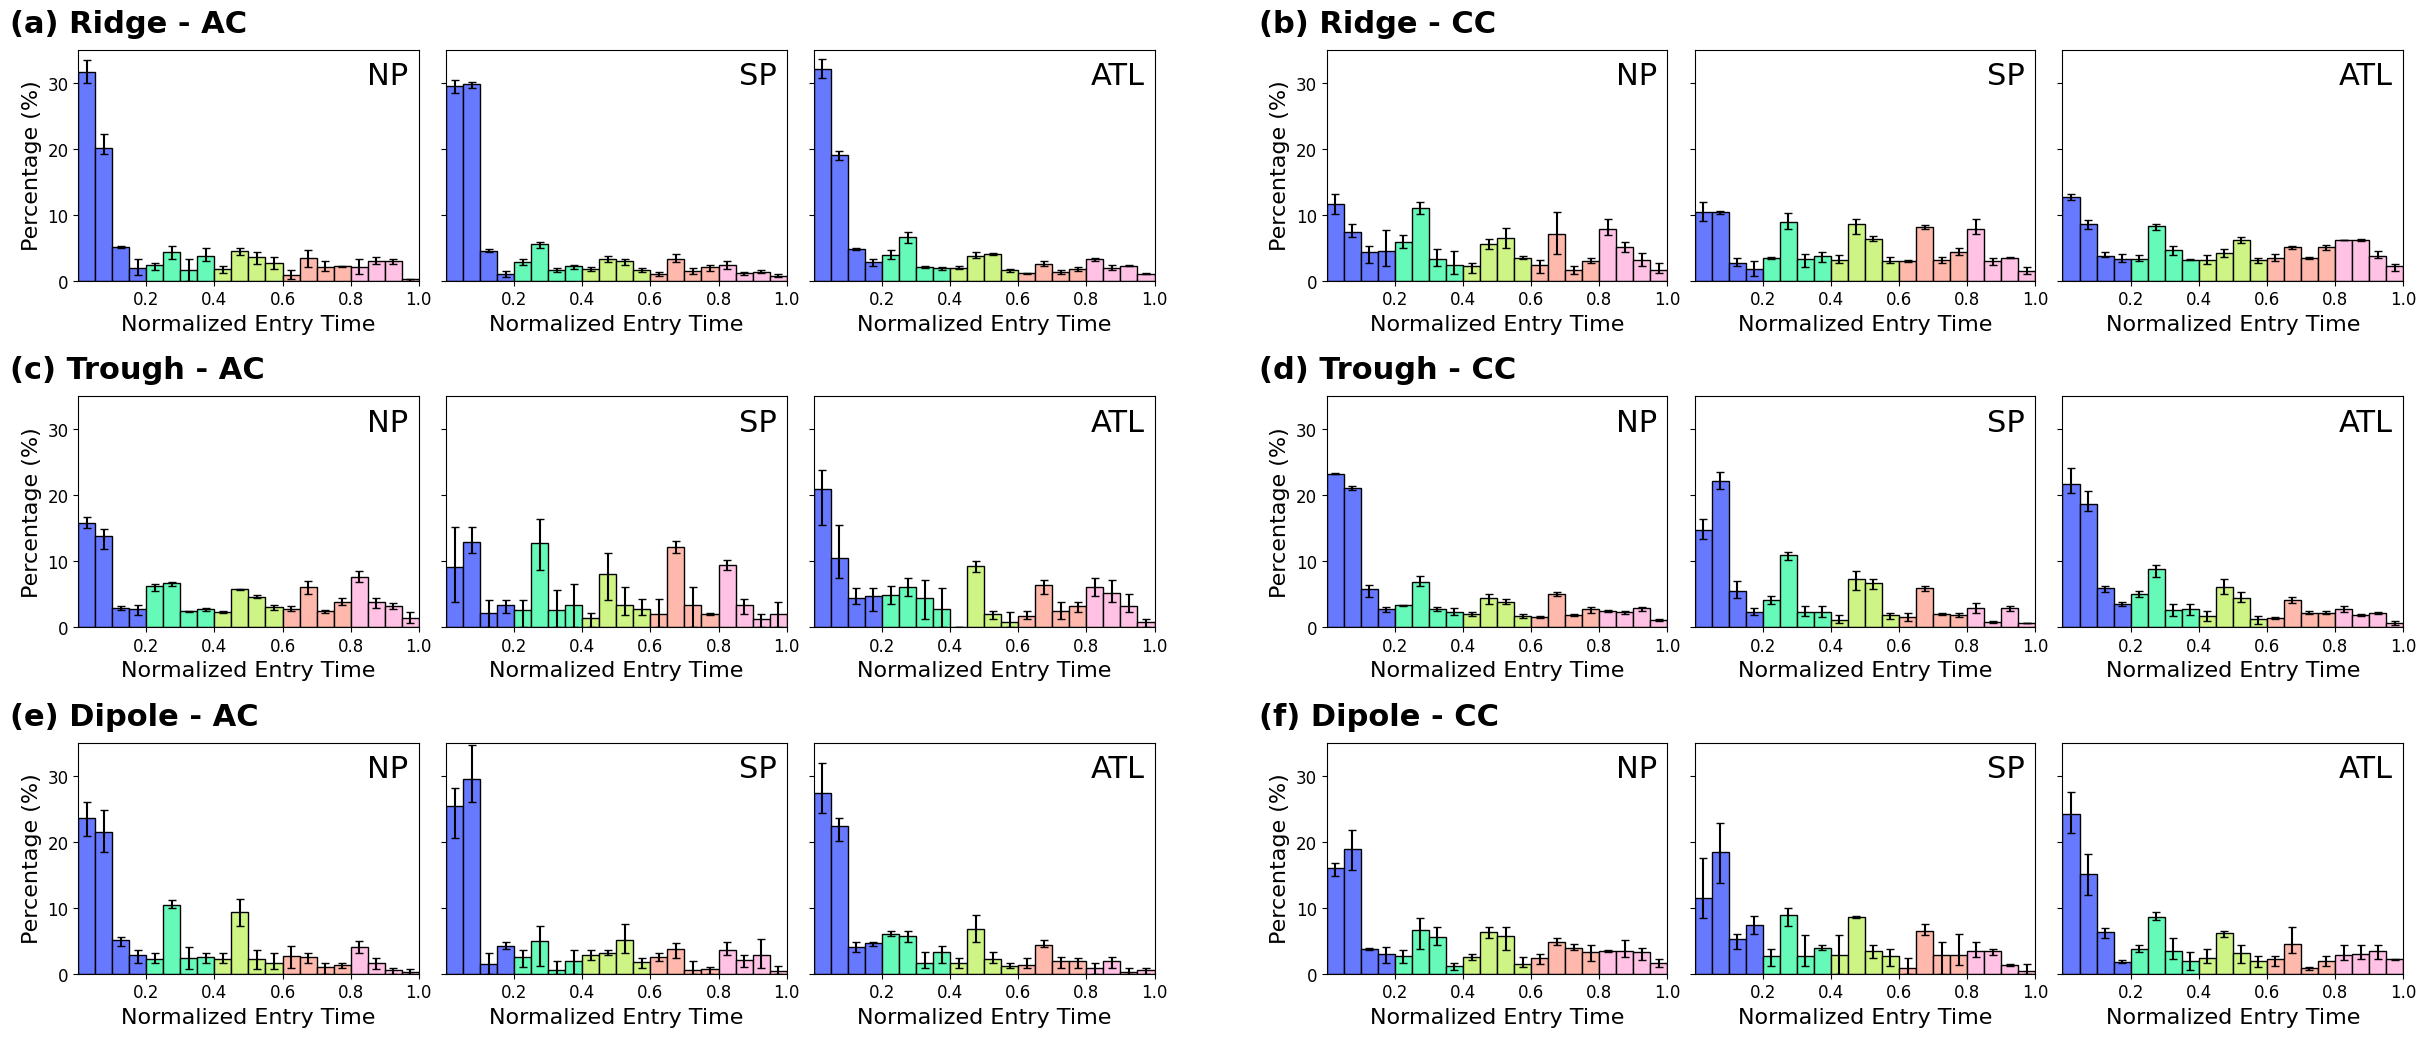

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================
# Basic settings
# =========================
bounds = np.arange(0, 1.20, 0.20)
cmap_part = gmtColors.sealand   
norm = BoundaryNorm(bounds, ncolors=cmap_part.N)

ss = "ALL"

datasets = ["ERA5", "MERRA2", "JRA3Q"]

typeids = [1, 2, 3]
typenames = {
    1: "Ridge",
    2: "Trough",
    3: "Dipole",
}

cycs = ["AC", "CC"]
regions = ["NP", "SP", "ATL"]
region_titles = {
    "NP": "NP",
    "SP": "SP",
    "ATL": "ATL",
}

# histogram bins
bounds_fine = np.arange(0, 1.05, 0.05)
bin_centers = (bounds_fine[:-1] + bounds_fine[1:]) / 2.0
bin_widths = np.diff(bounds_fine)


def calc_hist_percent(data, bounds_fine):
    hist_vals, hist_bins = np.histogram(data, bins=bounds_fine)
    hist_vals_percent = hist_vals / hist_vals.sum() * 100
    return hist_vals_percent, hist_bins


def load_entrytime_dict(typeid, cyc, ss="ALL"):
    entrytime_dict = {}

    for dtname_i in datasets:
        OUTDIR_i = OUT_DIR_List[dtname_i]

        entrytime_dict[dtname_i] = {
            "ATL": np.load(f"{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_ATL_{ss}.npy"),
            "NP":  np.load(f"{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_NP_{ss}.npy"),
            "SP":  np.load(f"{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_SP_{ss}.npy"),
        }

        print(
            typeid, cyc, dtname_i,
            len(entrytime_dict[dtname_i]["ATL"]),
            len(entrytime_dict[dtname_i]["NP"]),
            len(entrytime_dict[dtname_i]["SP"]),
            flush=True
        )

    return entrytime_dict


def addhist_multi(ax_hist, entrytime_dict, region,
                  ylimmax=35, ylab=True, title=None):

    hist_all = []

    for dtname_i in datasets:
        hist_percent_i, _ = calc_hist_percent(
            entrytime_dict[dtname_i][region],
            bounds_fine
        )
        hist_all.append(hist_percent_i)

    hist_all = np.array(hist_all)

    hist_mean = np.mean(hist_all, axis=0)
    hist_min = np.min(hist_all, axis=0)
    hist_max = np.max(hist_all, axis=0)

    yerr = np.vstack([
        hist_mean - hist_min,
        hist_max - hist_mean
    ])

    colors = cmap_part(norm(bin_centers))

    ax_hist.bar(
        bin_centers,
        hist_mean,
        width=bin_widths,
        align="center",
        color=colors,
        edgecolor="black",
        yerr=yerr,
        ecolor="black",
        capsize=3,
        linewidth=1
    )

    ax_hist.set_xlim(0, 1.0)
    ax_hist.set_ylim(0, ylimmax)
    ax_hist.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax_hist.tick_params(labelsize=12)

    if ylab:
        ax_hist.set_ylabel("Percentage (%)", fontsize=16)
    else:
        ax_hist.tick_params(labelleft=False)

    ax_hist.set_xlabel("Normalized Entry Time", fontsize=16)

    if title is not None:
        ax_hist.text(
            0.97, 0.95, title,
            transform=ax_hist.transAxes,
            ha="right", va="top",
            fontsize=22,
        )


def add_day_brackets(ax):
    y_arrow = 1.08
    y_text = 1.15

    day_edges = np.linspace(0.0, 1.0, 6)
    day_labels = ["day1", "day2", "day3", "day4", "day5"]

    for i in range(5):
        x0 = day_edges[i]
        x1 = day_edges[i + 1]
        xc = 0.5 * (x0 + x1)

        ax.annotate(
            "",
            xy=(x1, y_arrow),
            xytext=(x0, y_arrow),
            xycoords=("data", "axes fraction"),
            textcoords=("data", "axes fraction"),
            arrowprops=dict(
                arrowstyle="<->",
                lw=1.5,
                color="black",
                shrinkA=0,
                shrinkB=0
            ),
            annotation_clip=False
        )

        ax.text(
            xc, y_text, day_labels[i],
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontsize=11
        )

    for x in day_edges:
        ax.plot(
            [x, x],
            [y_arrow - 0.04, y_arrow + 0.04],
            transform=ax.get_xaxis_transform(),
            color="black",
            lw=1.2,
            clip_on=False
        )


# =========================
# Figure: 3 rows × 2 cols
# each panel contains 3 histograms
# =========================
fig = plt.figure(figsize=(30, 12))

outer = gridspec.GridSpec(
    nrows=3,
    ncols=2,
    figure=fig,
    wspace=0.16,
    hspace=0.50
)

panel_letters = ["a", "b", "c", "d", "e", "f"]

for irow, typeid in enumerate(typeids):
    for icol, cyc in enumerate(cycs):

        entrytime_dict = load_entrytime_dict(typeid, cyc, ss=ss)

        inner = gridspec.GridSpecFromSubplotSpec(
            1, 3,
            subplot_spec=outer[irow, icol],
            wspace=0.08
        )

        ax_h1 = fig.add_subplot(inner[0, 0])
        ax_h2 = fig.add_subplot(inner[0, 1])
        ax_h3 = fig.add_subplot(inner[0, 2])

        axes = [ax_h1, ax_h2, ax_h3]

        addhist_multi(ax_h1, entrytime_dict, "NP",
                      ylimmax=35, ylab=True,
                      title=region_titles["NP"])

        addhist_multi(ax_h2, entrytime_dict, "SP",
                      ylimmax=35, ylab=False,
                      title=region_titles["SP"])

        addhist_multi(ax_h3, entrytime_dict, "ATL",
                      ylimmax=35, ylab=False,
                      title=region_titles["ATL"])

        # # day1-day5 brackets above middle histogram
        # add_day_brackets(ax_h2)

        # panel title
        panel_idx = irow * 2 + icol
        ax_h1.text(
            -0.2, 1.05,
            f"({panel_letters[panel_idx]}) {typenames[typeid]} - {cyc}",
            transform=ax_h1.transAxes,
            fontsize=22,
            fontweight="bold",
            ha="left",
            va="bottom"
        )

plt.savefig("./FINAL_figures/Nature_ExtendedFig1.png", dpi=400, bbox_inches="tight")
plt.show()